In [1]:
#The folder structure has been changed and the code is updated accordingly. Copy-paste the imports code block in other relevant codes if needed.

#color bar updated and y-axis is set to altitude instead of height levels in Curtains
#mass-weighted random sampling and weighted R2
#new Dataset
#update output folder if required
#Opt for m_rsg or m_sg depending on the problem at hand

output_folder_name = '26-4-2026_new-rain-microphysics_curtains_ql_fraction'
Dendrogram_output_file_name = 'Dendrogram_ql_by_(ql+qi)_using_all_locals.png' #write .png
HC_output_file_name = 'HC_ql_by_(ql+qi)_using_all_locals.csv' #write .csv
pred_vs_actual_output_file_name = 'Pred_vs_Actual_ql_by_(ql+qi)_using_all_locals.png' #write .png

import time
overall_start_time = time.time()
import os
import importlib
import sys

# #Remove cached modules
# for module_name in list(sys.modules.keys()):
#     if 'dataset_init' in module_name:
#         del sys.modules[module_name]

# #Reimport
# from Tools import dataset_init

#To go up one level from 'Codes' sub-folder to 'MS' Folder, then the other sub-folders such as 'File_management' are accessible
MS_PATH = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(MS_PATH)

import numpy as np
import pandas as pd
#%matplotlib inline  #won't work for .py
import matplotlib.pyplot as plt
import xarray as xr

from File_management import json_file_editer as JFE
from Calculation import job_manager 
from Tools import dataset_init
from Log_management import Log

import xgboost as xgb
from xgboost import XGBClassifier
from xgboost import XGBRegressor
from xgboost import plot_importance

import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import r2_score

#random forest
import warnings
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

warnings.filterwarnings('ignore')

#ISLP
from matplotlib.pyplot import subplots
from statsmodels.datasets import get_rdataset
import sklearn.model_selection as skm
from ISLP import load_data, confusion_table
# from ISLP.models import ModelSpec as MS

from sklearn.tree import (DecisionTreeClassifier as DTC,
 DecisionTreeRegressor as DTR,
 plot_tree,
 export_text)
from sklearn.metrics import (accuracy_score,
 log_loss)
from sklearn.ensemble import \
 (RandomForestRegressor as RF,
 GradientBoostingRegressor as GBR)
from ISLP.bart import BART

import csv
#################################################################
# Log.init_log(os.path.join('./output'), filename=f"Log_ML.txt")
Log.init_log(os.path.join(MS_PATH, 'output'), filename="Log_ML.txt")
Log.add_to_log("Log nicely initialized ")

# options_json=JFE.get_json_data("options.json")
options_json = JFE.get_json_data(os.path.join(MS_PATH, "options.json"))

options_json["Header"]["status"]
chunks = {}
myJob = job_manager.JobManager(options_json)
# ds = dataset_init.ds_init_3d(myJob, chunks={}) 
ds = dataset_init.ds_init(myJob, chunks={}) 

The job folder path : /home/m/m301214/MS/output/Log_ML.txt
2026 Apr 26 08:45:31 > Log nicely initialized 
2026 Apr 26 08:45:31 > (DI0010) making data from P-O files requires small differences in the code, hardly automisable.
2026 Apr 26 08:45:31 > (DI0020) Starting PO dataset creation from /work/mh0066/m301130/projects/scheme_comparison/icon-mpim/build/experiments/pod0003
2026 Apr 26 08:45:31 > (DI0021) Found 35 time-varying files in date range
2026 Apr 26 08:45:31 > (DI0022) Loading vertical grid data from /work/mh0066/m301130/projects/scheme_comparison/icon-mpim/build/experiments/pod0003/pod0003_atm_vgrid_ml.nc
2026 Apr 26 08:45:31 > (DI0023) Grid variables available: ['clon_bnds', 'clat_bnds', 'height_bnds', 'height_2_bnds', 'zghalf', 'zg', 'dzghalf', 'clon', 'clat', 'height', 'height_2']
2026 Apr 26 08:45:31 > (DI0024) Dimensions in vgrid: {'ncells': 20971520, 'vertices': 3, 'height': 60, 'bnds': 2, 'height_2': 60}
2026 Apr 26 08:45:31 > (DI0037) Loading horizontal grid data from /

In [2]:
#Functions

#RH from SH
def RH_from_SH(P, SH, T, T_0= 273.16):
    RH = 0.26 * P * SH / np.exp(17.67 * (T - T_0) / (T - 29.65))
    return RH

#Modified R2 score
def modified_r_squared(y_test, y_test_pred, y_train):
    # Calculate the mean of the actual values
    mean_y_train = np.mean(y_train)

    # Calculate the total sum of squares
    ss_total = np.sum((y_test - mean_y_train)**2)

    # Calculate the residual sum of squares
    ss_residual = np.sum((y_test - y_test_pred)**2)

    # Calculate R^2 score
    r2_score = 1 - (ss_residual / ss_total)

    return r2_score

#Weighted R2 score 
def weighted_r_squared(y_true, y_pred, weight, y_train):
    # Calculate the mean of the actual values
    mean_y_train = np.mean(y_train)
    mean_y_true = np.mean(y_true)
    ss_total = np.sum( weight * (y_true - mean_y_train)**2)
    ss_residual = np.sum( weight * (y_true - y_pred)**2)
    r2_score = 1 - (ss_residual / ss_total)
    return r2_score


In [3]:
#Rename variables as per our notation
ds = ds.rename({'clw': 'ql'})
ds = ds.rename({'cli': 'qi'})
ds = ds.rename({'ta': 'T'})
ds = ds.rename({'hus': 'SH'})
ds = ds.rename({'pfull': 'P'})
ds = ds.rename({'cllvi': 'CLWP'})
ds = ds.rename({'clivi': 'CIP'})
ds = ds.rename({'wa': 'upward_air_velocity'})
ds = ds.rename({'ua': 'zonal_wind'})
ds = ds.rename({'va': 'meridional_wind'})
ds = ds.rename({'rho': 'air_density'})

In [5]:
wa_renamed = ds.sel(height=slice(31.0, 90.0), height_2=slice(31.0, 90.0))['upward_air_velocity'].rename({'height_2': 'height'})
ds = (
    ds
    .sel(height=slice(31.0, 90.0), height_2=slice(31.0, 90.0))
    .assign(upward_air_velocity=wa_renamed)
)

In [6]:
#Data Pre-processing

#subset of the original dataset

seed = 1
sample_frac = 0.001

ht=40
data=ds.sel(height=ht, height_2=ht) 

In [7]:
#Graupel Threshold set to 1e-6 kg/kg as mentioned in Michibata, 2024
# data = data.where(data['qg'] >= 1e-6)

total = data['ql'] + data['qi']
data['ql/(ql+qi)'] = data['ql'].where(total != 0, 0) / total.where(total != 0, 1)
data['qi/(ql+qi)'] = data['qi'].where(total != 0, 0) / total.where(total != 0, 1)

total_precipitates = data['qr'] + data['qs']+ data['qg']
data['qr/(qr+qs+qg)'] = data['qr'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)
data['qs/(qr+qs+qg)'] = data['qs'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)
data['qg/(qr+qs+qg)'] = data['qg'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)

df = data.to_dataframe() #.sample(frac=1, random_state=seed) #frac=sample_frac

# df = data.to_dataframe().sample(frac=sample_frac, random_state=seed)

dfs = [df]  
# for ht in range(32, 91, 5): #(32, 91, 5)
for ht in range(44, 91, 4): #(32, 91, 5)
    data = ds.sel(height=ht, height_2=ht)
    #Graupel Threshold set to 1e-6 kg/kg as mentioned in Michibata, 2024
    # data = data.where(data['qg'] >= 1e-6)

    total = data['ql'] + data['qi']
    data['ql/(ql+qi)'] = data['ql'].where(total != 0, 0) / total.where(total != 0, 1)
    data['qi/(ql+qi)'] = data['qi'].where(total != 0, 0) / total.where(total != 0, 1)

    total_precipitates = data['qr'] + data['qs']+ data['qg']
    data['qr/(qr+qs+qg)'] = data['qr'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)
    data['qs/(qr+qs+qg)'] = data['qs'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)
    data['qg/(qr+qs+qg)'] = data['qg'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)

    df_sampled=data.to_dataframe() #.sample(frac=1, random_state= seed+ht) #frac=sample_frac
    dfs.append(df_sampled) 
    print(f"Last value of clon in df with height {ht} is", df_sampled['clon'].iloc[-1])

df = pd.concat(dfs, ignore_index=True)


prod= len(dfs[0]) * len(dfs)
print("Expected length of df: ", prod)
print('Final length of df: ', len(df))


#OBtain lon and lat from clon and clat respectively
df['lon'] = df['clon']*180/np.pi #in degrees
df['lat'] = df['clat']*180/np.pi #in degrees

# #Setting coordinates range as the range of coordinates in Curtains dataset

# print("Minimum latitude: ", df['lat'].min())
# print("Maximum latitude: ", df['lat'].max())
# print("Minimum longitude: ", df['lon'].min())
# print("Maximum longitude: ", df['lon'].max())

# len_df_before_coordinate_slicing = len(df)
# print("Length of df before coordinate slicing: ", len_df_before_coordinate_slicing)

# #Slice the df
# df = df[(df['lat'].between(-4, 23)) & (df['lon'].between(-62, -20))] #These are the range of values of coordinates in the Curtains dataset

# print("Minimum latitude: ", df['lat'].min())
# print("Maximum latitude: ", df['lat'].max())
# print("Minimum longitude: ", df['lon'].min())
# print("Maximum longitude: ", df['lon'].max())

# len_df_after_coordinate_slicing = len(df)
# print("Length of df after coordinate slicing: ", len_df_after_coordinate_slicing)

#threshold
threshold = 5e-12
df_new = df[(df['qi'] + df['ql'] + df['qr'] + df['qg'] + df['qs']) >= threshold]

if df_new.empty:
    df_new = df

df = df_new

#RH data

df['RH']=RH_from_SH(df['P'], df['SH'], df['T'])

count=0
for i in df['RH']:
    if i>100 or i<0:
        count+=1
print("out-of-range count = ", count)
print("out-of-range count percent = ", 100*count/len(df['RH']), " %")

df['RH']= df['RH'].clip(lower=0, upper=100)

#Insert variables to the df
col=df.pop('RH')
df.insert(16, 'RH', col) #SH is at 15th position
#df.pop('SH')

df['ql+qi']=df['ql']+df['qi']
col=df.pop('ql+qi')
df.insert(26, 'ql+qi', col) 

#Include 'cloud liquid water path + cloud ice path' as a feature.
df['CLWP+CIP']=df['CLWP']+df['CIP']
col=df.pop('CLWP+CIP')
df.insert(27, 'CLWP+CIP', col) 

#Adding another column; qr+qg+qs and use it later as an input feature
df['qr+qg+qs'] = df['qr'] + df['qg'] + df['qs']
col=df.pop('qr+qg+qs')
df.insert(30, 'qr+qg+qs', col)

df['qg/(qs+qg)'] = df['qg'] / (df['qs']+ df['qg']) 
# print('Number of NaN values in qg/(qs+qg) column: ', df['qg/(qs+qg)'].isna().sum())
df = df.dropna(subset=['qg/(qs+qg)'])
# print('Number of NaN values in qg/(qs+qg) column now: ', df['qg/(qs+qg)'].isna().sum())

#mass-weighted condensates
df['m_ci']=df['dzghalf']*df['air_density']*df['cell_area']* (df['ql']+df['qi'])
col=df.pop('m_ci')
df.insert(28, 'm_ci', col) 

#mass-weighted random sampling
df['m_sg']=df['dzghalf']*df['air_density']*df['cell_area']* (df['qs']+df['qg'])
col=df.pop('m_sg')
df.insert(28, 'm_sg', col) 

df = df.sort_values(by='m_ci', ascending=False)
df = df.reset_index(drop=True)

total_mass = df['m_ci'].sum()
df['cum_mass'] = df['m_ci'].cumsum()
col=df.pop('cum_mass')
df.insert(29, 'cum_mass', col) 

n_samples= int(np.floor(len(df) * 0.1)) #we are taking a way smaller dataset because of this 
# n_samples= int(np.floor(len(df))) 
np.random.seed(29)
random_values = np.random.uniform(0, df['cum_mass'].max(), size=n_samples)
print('Random values: ', random_values)
# indices= np.searchsorted(df['cum_mass'].values, random_values)
indices = np.clip(np.searchsorted(df['cum_mass'].values, random_values), 0, len(df) - 1)
df_orig=df
df = df.iloc[indices].reset_index(drop=True)


Last value of clon in df with height 44 is 1.3343108942333097
Last value of clon in df with height 48 is 1.3343108942333097
Last value of clon in df with height 52 is 1.3343108942333097
Last value of clon in df with height 56 is 1.3343108942333097
Last value of clon in df with height 60 is 1.3343108942333097
Last value of clon in df with height 64 is 1.3343108942333097
Last value of clon in df with height 68 is 1.3343108942333097
Last value of clon in df with height 72 is 1.3343108942333097
Last value of clon in df with height 76 is 1.3343108942333097
Last value of clon in df with height 80 is 1.3343108942333097
Last value of clon in df with height 84 is 1.3343108942333097
Last value of clon in df with height 88 is 1.3343108942333097
Expected length of df:  272629760
Final length of df:  272629760
out-of-range count =  975239
out-of-range count percent =  1.1849365017533977  %
Random values:  [9.49334808e+12 3.13132299e+12 8.05140783e+11 ... 1.08518133e+13
 3.80003543e+11 1.07335858e+1

In [8]:
df.columns

Index(['clon', 'clat', 'cell_area', 'pr', 'tas', 'CIP', 'CLWP', 'qgvi', 'qrvi',
       'qsvi', 'ql', 'qi', 'qr', 'qg', 'qs', 'SH', 'RH', 'T',
       'upward_air_velocity', 'air_density', 'dzghalf', 'zg', 'zonal_wind',
       'meridional_wind', 'P', 'height', 'ql+qi', 'CLWP+CIP', 'm_sg',
       'cum_mass', 'm_ci', 'height_2', 'ql/(ql+qi)', 'qr+qg+qs', 'qi/(ql+qi)',
       'qr/(qr+qs+qg)', 'qs/(qr+qs+qg)', 'qg/(qr+qs+qg)', 'lon', 'lat',
       'qg/(qs+qg)'],
      dtype='str')

Hierarchical Clustering of features

Shape of transposed DataFrame: (13, 8229377)
Shape of linkage matrix: (12, 4)
First 10 rows of linkage DataFrame:
    c1  c2  distance  size
0   8   9  0.011739     2
1   3  12  0.080966     2
2   2   4  0.151096     2
3   5  11  0.222934     2
4  13  14  0.246507     4
5  15  17  0.553436     6
6   0   7  0.677853     2
7  10  18  0.840086     7
8   1   6  0.948318     2
9  16  19  1.000753     4


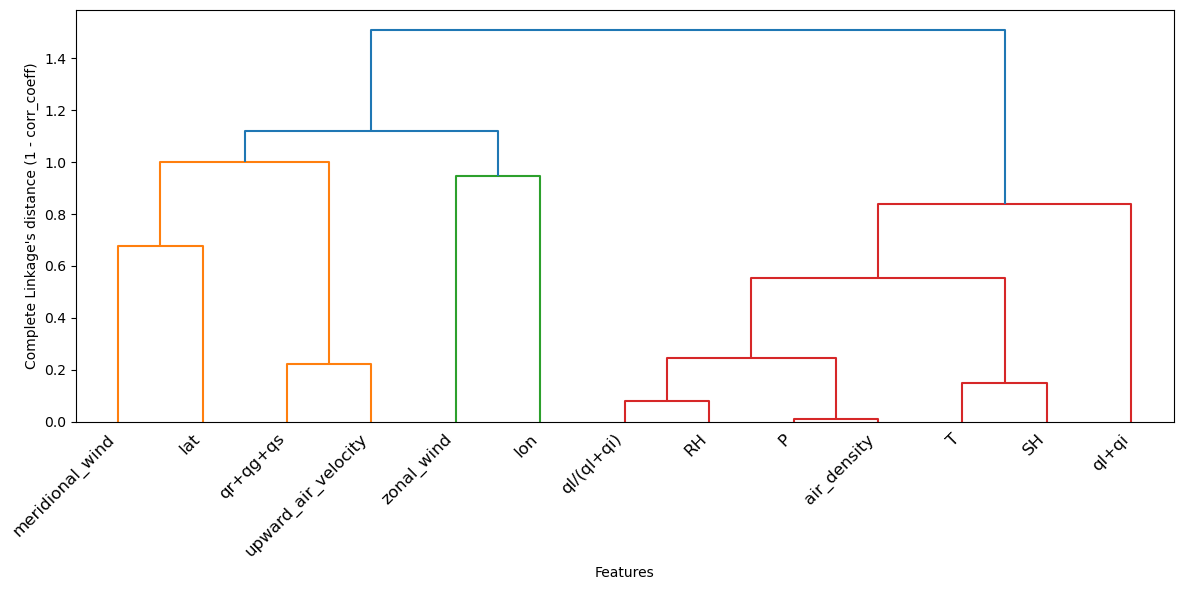

In [9]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.preprocessing import StandardScaler

# df_orig=df.copy()
#Select ft's

#'CLWP+CIP' has been dropped from HC
feature_names= ['lat','lon','SH' ,'RH','T', 'upward_air_velocity', 'zonal_wind','meridional_wind','air_density','P','ql+qi','qr+qg+qs','ql/(ql+qi)'] # [lat, lon, RH,T,upward_air_velocity,zonal_wind,meridional_wind,P,ql+qi,qr+qg+qs]
# feature_names= ['lat','lon','SH' ,'RH','T','upward_air_velocity','zonal_wind','meridional_wind','air_density','P','ql+qi','qr+qg+qs','CLWP+CIP'] # [lat, lon, RH,T,upward_air_velocity,zonal_wind,meridional_wind,P,ql+qi,qr+qg+qs]
# feature_names= ['lat','lon','SH' ,'RH','T','upward_air_velocity','zonal_wind','meridional_wind','air_density','P','ql+qi','qr+qg+qs'] # [lat, lon, RH,T,upward_air_velocity,zonal_wind,meridional_wind,P,ql+qi,qr+qg+qs]
df_features = df[feature_names]

#Standardize ft's
scaler= StandardScaler()
df_scaled= scaler.fit_transform(df_features)
df_scaled= pd.DataFrame(df_scaled, columns=df_features.columns)

#Transpose so ft's are in rows
df_transposed = df_scaled.transpose()
print("Shape of transposed DataFrame:", np.shape(df_transposed))

# linked=linkage(df_transposed, method='complete', metric='euclidean')
linked=linkage(df_transposed, method='complete', metric='correlation')
print("Shape of linkage matrix:", np.shape(linked))

df_linked= pd.DataFrame(linked, columns=['c1','c2','distance','size'])
df_linked[['c1','c2','size']]= df_linked[['c1','c2','size']].astype('int')
print("First 10 rows of linkage DataFrame:\n", df_linked.head(10))

#Create the Dendrogram
plt.figure(figsize=(12,6))
dendrogram(linked,
            orientation='top',
              labels=df_transposed.index,
                distance_sort='descending',
                  show_leaf_counts=True)

plt.xlabel('Features')
# plt.ylabel('Complete Linkage\'s distance (Euclidean)')
plt.ylabel('Complete Linkage\'s distance (1 - corr_coeff)')

plt.xticks(rotation=45, ha='right')   #tilt labels
plt.tight_layout()                    #adjust spacing automatically

Dendrogram_output_path = os.path.join('../output', output_folder_name, Dendrogram_output_file_name)
plt.savefig(Dendrogram_output_path,  bbox_inches='tight') #bbox_inches='tight' so that labels don't get cut off

plt.show()

In [10]:
#Now, let's set a limit on the number of clusters
num_clusters=4

labels= fcluster(linked, t=num_clusters, criterion='maxclust')
print("Cluster labels for each feature:", labels)

correlations=[]
for col in df_features.columns:
    corr=df['ql/(ql+qi)'].corr(df[col])
    corr=round(corr,3)
    correlations.append(corr)

df_clusters= pd.DataFrame(list(zip(df_features.columns, labels, correlations)),
                          columns=['feature', 'cluster', 'corr'])

df_clusters['abs_corr']= df_clusters['corr'].abs()

df_clusters.sort_values(by=['cluster','abs_corr'], ascending=[True, False], inplace=True) #inplace=True changes this very df itself
df_clusters.reset_index(drop=True, inplace=True) #drop=True prevents the old indices from being added as a column
print("DataFrame of clustered features:\n", df_clusters)

HC_output_path = os.path.join('../output', output_folder_name, HC_output_file_name)
df_clusters.to_csv(HC_output_path, index=False)



Cluster labels for each feature: [4 2 1 1 1 3 2 4 1 1 1 3 1]


DataFrame of clustered features:
                 feature  cluster   corr  abs_corr
0            ql/(ql+qi)        1  1.000     1.000
1                    RH        1  0.919     0.919
2                     T        1  0.848     0.848
3                     P        1  0.794     0.794
4           air_density        1  0.753     0.753
5                    SH        1  0.580     0.580
6                 ql+qi        1  0.428     0.428
7            zonal_wind        2 -0.302     0.302
8                   lon        2 -0.043     0.043
9   upward_air_velocity        3  0.058     0.058
10             qr+qg+qs        3  0.017     0.017
11                  lat        4 -0.109     0.109
12      meridional_wind        4 -0.063     0.063


In [10]:
#tldr: copy the above table to excel and use your domain knowledge and do data manipuln.

#long version (as mentioned in the Medium article):
# At this point, you should copy these results into a program like Excel where they can be manipulated. The above process will produce statistically optimal clusters but you should rearrange them so they become more intuitive. Additionally, you may want to divide some of the larger clusters and combine some of the smaller ones. For example, cluster 1 has 19 features but cluster 9 only has 3. Crucially, this is the point where you incorporate domain knowledge and other factors into the feature shortlist.

In [11]:
# c1_features= df_clusters[df_clusters['cluster']==1]['feature'].tolist()
# c2_features= df_clusters[df_clusters['cluster']==2]['feature'].tolist()
# c3_features= df_clusters[df_clusters['cluster']==3]['feature'].tolist()

# print("Number of features in cluster 1:", len(c1_features))
# print("Number of features in cluster 2:", len(c2_features))
# print("Number of features in cluster 3:", len(c3_features))

# #Plot correlns of ft's in clusters 2 and 3
# corr = df_features[np.append(c2_features, c3_features)].corr()

# #plot correln. matrix
# plt.figure(figsize=(5,4))

# sns.heatmap(corr,
#             annot=True,
#             cmap='coolwarm',
#             linewidths=0.5,
#             fmt=".2f",
#             annot_kws={"size":5},
#             vmin=-1, vmax=1)

# plt.title('Cluster 2 and 3')

In [12]:
# #Plot correlns of ft's in clusters 1 and 2
# corr = df_features[np.append(c1_features, c2_features)].corr()

# #plot correln. matrix
# plt.figure(figsize=(5,4))

# sns.heatmap(corr,
#             annot=True,
#             cmap='coolwarm',
#             linewidths=0.5,
#             fmt=".2f",
#             annot_kws={"size":5},
#             vmin=-1, vmax=1)

# plt.title('Cluster 1 and 2')

In [13]:
# #Plot correlns of ft's in clusters 1 and 3
# corr = df_features[np.append(c1_features, c3_features)].corr()

# #plot correln. matrix
# plt.figure(figsize=(5,4))

# sns.heatmap(corr,
#             annot=True,
#             cmap='coolwarm',
#             linewidths=0.5,
#             fmt=".2f",
#             annot_kws={"size":5},
#             vmin=-1, vmax=1)

# plt.title('Cluster 1 and 3')

In [14]:
'''
Note in the Medium article: This is exactly the point of feature clustering. We have created groups of features that will provide similar information about the target variable. At the same time, they will provide different information to features in the other groups. If we select 1 or 2 features from each cluster, we will reduce the amount of redundant features in our shortlist.

Another way of looking at this process is that it reduces the dimensionality of the feature space. This is done in a way so that we end up with a set of features that will not all be highly correlated. There is another process that does exactly this — principal component analysis.

The important difference is that features created using PCA are not interpretable. They consist of information from multiple features. Using hierarchical clustering, we retain the original features and their relationship with the target variable will be easier to explain.

'''

'\nNote in the Medium article: This is exactly the point of feature clustering. We have created groups of features that will provide similar information about the target variable. At the same time, they will provide different information to features in the other groups. If we select 1 or 2 features from each cluster, we will reduce the amount of redundant features in our shortlist.\n\nAnother way of looking at this process is that it reduces the dimensionality of the feature space. This is done in a way so that we end up with a set of features that will not all be highly correlated. There is another process that does exactly this — principal component analysis.\n\nThe important difference is that features created using PCA are not interpretable. They consist of information from multiple features. Using hierarchical clustering, we retain the original features and their relationship with the target variable will be easier to explain.\n\n'

In [11]:
feature_names

['lat',
 'lon',
 'SH',
 'RH',
 'T',
 'upward_air_velocity',
 'zonal_wind',
 'meridional_wind',
 'air_density',
 'P',
 'ql+qi',
 'qr+qg+qs',
 'ql/(ql+qi)']

In [12]:
feature_names= [feature for feature in feature_names if feature not in ('CLWP+CIP', 'SH', 'air_density', 'ql/(ql+qi)')]

In [13]:
feature_names

['lat',
 'lon',
 'RH',
 'T',
 'upward_air_velocity',
 'zonal_wind',
 'meridional_wind',
 'P',
 'ql+qi',
 'qr+qg+qs']

In [14]:

X = df[feature_names] 
y = df['ql/(ql+qi)'].values 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.01, random_state=5)

#Train using xgb
#The following 'best' parameter values have been approximated from the values otained from the previous runs to find the best parameters in different datasets

# best_parameters= grid_search.best_params_
best_n_estimators=100 #best_parameters['n_estimators']
best_min_child_weight=30 #best_parameters['min_child_weight']
best_max_depth=10 #best_parameters['max_depth']
best_learning_rate=0.1 #best_parameters['learning_rate']

#XGBoost
# fit model
model = XGBRegressor(n_estimators=best_n_estimators, min_child_weight= best_min_child_weight, max_depth=best_max_depth, learning_rate=best_learning_rate, n_jobs=-1, random_state=0) #verbosity=3 (optional)

##Training
training_start_time = time.time()
model.fit(X_train, y_train)
training_end_time = time.time()
training_elapsed_time = training_end_time - training_start_time
print(f"Training- Elapsed time: {training_elapsed_time/60:.4f} minutes")


Training- Elapsed time: 0.3740 minutes


In [15]:
#z_half values in metres (91 values)
altitude_m = [
    75000.000, 72454.585, 70016.259, 67611.928, 65275.653, 63005.576, 60799.957,
    58657.165, 56575.665, 54545.104, 52558.113, 50620.105, 48723.838, 46883.751,
    45098.717, 43367.665, 41689.576, 40063.480, 38488.454, 36963.617, 35488.131,
    34061.192, 32682.038, 31349.939, 30064.198, 28824.149, 27629.160, 26478.623,
    25376.214, 24326.735, 23332.342, 22396.409, 21515.499, 20686.378, 19906.001,
    19171.503, 18480.185, 17829.510, 17217.088, 16640.670, 16098.140, 15587.505,
    15106.891, 14654.532, 14228.766, 13816.274, 13416.274, 13016.274, 12616.274,
    12216.274, 11816.274, 11416.274, 11016.274, 10616.274, 10216.274,  9816.274,
     9416.274,  9016.274,  8616.274,  8216.274,  7816.274,  7416.274,  7016.274,
     6616.274,  6216.274,  5816.274,  5416.274,  5024.590,  4646.717,  4282.624,
     3932.291,  3595.712,  3272.894,  2963.856,  2668.637,  2387.292,  2119.895,
     1866.546,  1627.369,  1402.521,  1192.196,   996.632,   816.127,   651.048,
      501.859,   369.154,   253.718,   156.631,    79.492,    25.000,     0.000
]
altitude_kms = [a / 1000 for a in altitude_m]   
altitude_kms = altitude_kms[-51:] #last 51 values matches height_full 40 to 90
print("Altitude values in km:\n", altitude_kms)

Altitude values in km:
 [16.09814, 15.587504999999998, 15.106891, 14.654532, 14.228766, 13.816274, 13.416274, 13.016274, 12.616273999999999, 12.216274, 11.816274, 11.416274, 11.016274, 10.616273999999999, 10.216274, 9.816274, 9.416274, 9.016274, 8.616273999999999, 8.216274, 7.816274, 7.4162740000000005, 7.016274, 6.616274000000001, 6.216274, 5.816274, 5.4162740000000005, 5.02459, 4.646717, 4.282624, 3.932291, 3.595712, 3.272894, 2.9638560000000003, 2.6686370000000004, 2.387292, 2.119895, 1.866546, 1.6273689999999998, 1.402521, 1.1921959999999998, 0.996632, 0.8161269999999999, 0.651048, 0.5018589999999999, 0.369154, 0.253718, 0.156631, 0.07949200000000001, 0.025, 0.0]


In [ ]:
files = [
    "orcestra_ec-curtain_2024-08-11_15h51.nc",
    "orcestra_ec-curtain_2024-08-13_15h39.nc",
    "orcestra_ec-curtain_2024-08-16_16h13.nc",
    "orcestra_ec-curtain_2024-08-18_16h03.nc",
    "orcestra_ec-curtain_2024-08-22_15h41.nc",
    "orcestra_ec-curtain_2024-08-25_16h11.nc",
    "orcestra_ec-curtain_2024-08-27_16h01.nc",
    "orcestra_ec-curtain_2024-08-29_15h51.nc",
    "orcestra_ec-curtain_2024-08-31_15h38.nc",
    "orcestra_ec-curtain_2024-09-03_16h08.nc",
    "orcestra_ec-curtain_2024-09-07_15h47.nc",
    "orcestra_ec-curtain_2024-09-09_17h05.nc",
    "orcestra_ec-curtain_2024-09-12_17h35.nc",
    "orcestra_ec-curtain_2024-09-14_17h25.nc",
    "orcestra_ec-curtain_2024-09-16_17h15.nc",
    "orcestra_ec-curtain_2024-09-19_17h43.nc",
    "orcestra_ec-curtain_2024-09-21_17h33.nc",
    "orcestra_ec-curtain_2024-09-23_17h22.nc",
    "orcestra_ec-curtain_2024-09-24_18h02.nc",
    "orcestra_ec-curtain_2024-09-26_17h51.nc",
    "orcestra_ec-curtain_2024-09-28_17h41.nc"
]


# files = sorted(files)

print('The number of files present: ', len(files))
file_number=1

r2_curtain_list=[]
modified_r2_curtain_list=[]
weighted_r2_curtain_list=[]
rmse_curtain_list=[]

for file_name in files:
        print('File number: ', file_number)
        file_number+=1
        
        base_path = '/work/mh0492/m301067/ec-curtains/data/curtains/build-master-031224-new-rain'

        ds_curtain = xr.open_dataset(os.path.join(base_path, file_name))

        #Rename variables as per our notation
        ds_curtain = ds_curtain.rename({'qc': 'ql'})
        ds_curtain = ds_curtain.rename({'ta': 'T'})
        ds_curtain = ds_curtain.rename({'qv': 'SH'})
        ds_curtain = ds_curtain.rename({'pfull': 'P'})
        ds_curtain = ds_curtain.rename({'cllvi': 'CLWP'})
        ds_curtain = ds_curtain.rename({'qivi': 'CIP'})
        ds_curtain = ds_curtain.rename({'wa': 'upward_air_velocity'})
        ds_curtain = ds_curtain.rename({'ua': 'zonal_wind'})
        ds_curtain = ds_curtain.rename({'va': 'meridional_wind'})
        ds_curtain = ds_curtain.rename({'rho': 'air_density'})
        ds_curtain = ds_curtain.rename({'track_lat': 'lat'})
        ds_curtain = ds_curtain.rename({'track_lon': 'lon'})

        #Set dzghalf values in the ds_curtain

        zghalf_top    = ds_curtain['zghalf'].sel(height_half=slice(1, 90))   
        zghalf_bottom = ds_curtain['zghalf'].sel(height_half=slice(2, 91))   

        #Compute cell thickness (top altitude minus bottom altitude)
        dzghalf = zghalf_top.values - zghalf_bottom.values 

        #Store this with the height_full coordinate
        ds_curtain['dzghalf'] = xr.DataArray(
            dzghalf,
            dims=['height_full', 'track'],
            attrs={'long_name': 'Grid cell thickness (half-level difference)', 'units': 'm'}
        )

        #Cloud water Threshold set to 1e-6 kg/kg as mentioned in Michibata, 2024
        # ds_curtain = ds_curtain.where(ds_curtain['qg'] >= 1e-6)

        #Set Area of every cell in ds_curtain
        #Here we assume a constant area of 1562500 square meters, since the resolution is 625 meters

        # n_height = ds_curtain.dims['height_full']
        # n_track  = ds_curtain.dims['track']

        # ds_curtain['area_cell'] = xr.DataArray(
        #     np.full((n_height, n_track), 1562500.0),
        #     dims=['height_full', 'track'],
        #     attrs={'long_name': 'Grid cell area', 'units': 'm^2'}
        # )
        cell_area = 1562500 #in square meters

        #Tropospheric subset
        ds_curtain_subset = ds_curtain.sel(
            time=ds_curtain.time[0],
            height_full=slice(40, 90),
            height_half=slice(40, 90)
        )

        #Set height_full instead of height_half as the vertical coordinate for upward_air_velocity
        wa_renamed = ds_curtain.sel(height_full=slice(40.0, 90.0), height_half=slice(40.0, 90.0))['upward_air_velocity'].rename({'height_half': 'height_full'})
        ds_curtain = (
            ds_curtain
            .sel(height_full=slice(40.0, 90.0), height_half=slice(40.0, 90.0))
            .assign(upward_air_velocity=wa_renamed)
        )

        ds_curtain_subset["RH"] = RH_from_SH(
            ds_curtain_subset["P"],
            ds_curtain_subset["SH"],
            ds_curtain_subset["T"]
        )


        vars_full = ["SH", "ql", "qi", "qs", "qg", "qr", "T", "P", "upward_air_velocity", "zonal_wind", "meridional_wind", "CLWP",  "CIP" , "qgvi", "qrvi", "qsvi", "zg", "RH", "lon", "lat", "dzghalf", "air_density"]
        df_full = ds_curtain_subset[vars_full].to_dataframe().reset_index()

        #Calculate condensate and precipitate fractions
        total = df_full['ql'] + df_full['qi']
        df_full['ql/(ql+qi)'] = df_full['ql'].where(total != 0, 0) / total.where(total != 0, 1)
        df_full['qi/(ql+qi)'] = df_full['qi'].where(total != 0, 0) / total.where(total != 0, 1)

        total_precipitates = df_full['qr'] + df_full['qs'] + df_full['qg']
        df_full['qr/(qr+qs+qg)'] = df_full['qr'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)
        df_full['qs/(qr+qs+qg)'] = df_full['qs'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)
        df_full['qg/(qr+qs+qg)'] = df_full['qg'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)

        old_df_full_len = len(df_full)
        print("Length of the old df_full: ", old_df_full_len)
        threshold = 5e-12
        df_full_new = df_full[(df_full['ql'] + df_full['qi'] + df_full['qr'] + df_full['qg'] + df_full['qs']) >= threshold]
        # print('df_full- After threshold-1:')
        # print(df_full_new)
        if df_full_new.empty:
            df_full_new = df_full

        df_full = df_full_new
        new_df_full_len = len(df_full)
        # print('df_full after threshold-2:\n', df_full)
        print("Length of the new df_full: ", new_df_full_len)
        percent_data_removed=100*(old_df_full_len - new_df_full_len)/old_df_full_len
        print("Percentage of data removed after setting the threshold: ", percent_data_removed, "%") #work on this
        print("Percentage of cells having sum of condensates and preicipitates greater than the threshold: ", (100-percent_data_removed),"%")

        count=0
        for i in df_full['RH']:
            if i>100 or i<0:
                count+=1
        print("Out_of_range count = ", count)
        print("Out_of_range count percent = ", 100*count/len(df_full['RH']) ,"%")

        df_full['RH']= df_full['RH'].clip(lower=0, upper=100)
        
        #Add other relevant features to df_full
        df_full['ql+qi']=df_full['ql']+df_full['qi']
        df_full['CLWP+CIP']=df_full['CLWP']+df_full['CIP'] #rename curtain variables too!
        df_full['qr+qg+qs'] = df_full['qr'] + df_full['qg'] + df_full['qs']

        # final_df_full_length=df_full.length
        final_df_full_length=len(df_full)
        print("The final length of the dataframe is ", final_df_full_length)

        diff = (old_df_full_len - final_df_full_length)
        percent_diff=(diff*100/old_df_full_len)
        print("Percent difference in the lengths of old df_full and final df_full is: ", percent_diff, "%")
        print("Percentage of cells having sum of condensates and preicipitates greater than the threshold: ", (100-percent_diff), "%")

       
        df_full = df_full.dropna(subset=['ql/(ql+qi)'])

        if df_full.empty:
            print(f"Skipping {file_name}: no valid Cloud water rows after filtering.")
            plt.close('all')
            continue

        # #mass-weighted random sampling
        # df_full['m_sg']=df_full['dzghalf']*df_full['air_density']*cell_area* (df_full['qs']+df_full['qg'])

        # df_full = df_full.sort_values(by='m_sg', ascending=False)
        # df_full = df_full.reset_index(drop=True)

        # total_mass = df_full['m_sg'].sum()
        # df_full['cum_mass'] = df_full['m_sg'].cumsum()

        # n_samples= int(np.floor(len(df_full) * 0.1)) #we are taking a way smaller dataset because of this 
        # # n_samples= int(np.floor(len(df_full))) 
        # np.random.seed(29)
        # random_values = np.random.uniform(0, df_full['cum_mass'].max(), size=n_samples)
        # print('Random values: ', random_values)
        # indices= np.searchsorted(df_full['cum_mass'].values, random_values)
        # df_full_orig=df_full
        # df_full = df_full.iloc[indices].reset_index(drop=True)

        curtain_feature_names= ['lat', 'lon', 'RH', 'T', 'upward_air_velocity', 'zonal_wind', 'meridional_wind', 'P', 'ql+qi', 'qr+qg+qs'] # [track_lat,track_lon,RH,T,upward_air_velocity,zonal_wind,meridional_wind,P,ql+qi,qr+qg+qs]
        # X_curtain = df_full[curtain_feature_names].values 
        X_curtain = df_full[curtain_feature_names]
        y_curtain = df_full['ql/(ql+qi)'].values
        X_curtain_train, X_curtain_test, y_curtain_train, y_curtain_test = train_test_split(X_curtain, y_curtain, test_size=0.99, random_state=5)
        
        #XGBoost
        #Training is already done

        ##Prediction
        prediction_start_time = time.time()
        y_pred = model.predict(X_curtain_test)
        prediction_end_time = time.time()
        prediction_elapsed_time = prediction_end_time - prediction_start_time
        print(f"Prediction- Elapsed time: {prediction_elapsed_time/60:.4f} minutes")

        print("max value of the fraction: ", np.max(y_pred))
        print("min value of the fraction: ", np.min(y_pred))

        count=0
        for i in y_pred:
            if i>1 or i<0:
                # print(i)
                count+=1
        print("Out-of-range count = ", count)
        print("Out-of-range count percent = ", 100*count/len(y_pred) , " %")

        y_pred = np.clip(y_pred, 0, 1)
        # y_curtain_test=y_curtain_test.ravel()
        # y_pred=y_pred.ravel()

        #Error Analysis on TEST data
        #mse
        mse= np.mean((y_curtain_test- y_pred)**2)
        print('MSE_Test: ', mse)

        #rmse_test
        rmse_TEST = np.sqrt(np.mean((y_curtain_test - y_pred)**2))
        print(f'RMSE_TEST: {rmse_TEST}')
        rmse_curtain_list.append(rmse_TEST) 

        #mae_TEST
        mae_TEST = np.mean(abs(y_curtain_test - y_pred))
        print(f'mae_TEST: {mae_TEST}')

        #R2_test_sklearn
        r2_sklearn = r2_score(y_curtain_test, y_pred)
        print("R² score: ", r2_sklearn)
        r2_curtain_list.append(r2_sklearn)

        #Modified R2 score
        modified_r2 = modified_r_squared(y_curtain_test, y_pred, y_train)
        print("Modified R² score: ", modified_r2)
        modified_r2_curtain_list.append(modified_r2)

        #weighted_R2_test
        df_full_test= df_full.loc[X_curtain_test.index]
        weight = cell_area*df_full_test['dzghalf']*df_full_test['air_density']*(df_full_test['ql'] + df_full_test['qi'] ) 

        weighted_r2 = weighted_r_squared(y_curtain_test, y_pred, weight, y_train)
        print("Weighted R² score: ", weighted_r2)
        weighted_r2_curtain_list.append(weighted_r2)

        from matplotlib.ticker import MaxNLocator

        plt.rcParams['font.family'] = 'sans-serif'
        plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
        plt.rcParams['font.size'] = 11
        plt.rcParams['axes.linewidth'] = 1.2
        plt.rcParams['xtick.major.width'] = 1.2
        plt.rcParams['ytick.major.width'] = 1.2
        plt.rcParams['xtick.major.size'] = 5
        plt.rcParams['ytick.major.size'] = 5

        fig, ax = plt.subplots(figsize=(7, 6), dpi=300)

        #Create hexbin plot with reversed colormap (light to dark)
        #Using viridis_r for reversed viridis, or try 'YlOrRd' for yellow-orange-red
        hb = ax.hexbin(
            # y_curtain_test.flatten(), 
            # y_curtain_test.values, 
            y_curtain_test, 
            y_pred.flatten(), 
            gridsize=40,
            cmap='viridis_r',  # Reversed: dark (low) to bright yellow (high)
            bins='log',
            mincnt=1,
            linewidths=0.2,
            edgecolors='face'
        )

        #Add colorbar with proper formatting
        cbar = plt.colorbar(hb, ax=ax, label='Count (log$_{10}$ scale)')
        cbar.ax.tick_params(labelsize=10)

        #Calculate axis limits with padding
        data_min = min(y_curtain_test.min(), y_pred.min())
        data_max = max(y_curtain_test.max(), y_pred.max())
        padding = (data_max - data_min) * 0.05
        ax.set_xlim(data_min - padding, data_max + padding)
        ax.set_ylim(data_min - padding, data_max + padding)

        #Perfect prediction line
        ax.plot(
            [data_min - padding, data_max + padding],
            [data_min - padding, data_max + padding],
            'k--',  # Black dashed line
            lw=1.5,
            alpha=0.7,
            label='Perfect prediction',
            zorder=3
        )

        #Add statistics text box
        # textstr = f'$R^2$ = {r2_sklearn:.3f}\nWeighted $R^2$ = {weighted_r2:.3f}\nRMSE = {rmse_TEST:.3f}'
        textstr = f'Weighted $R^2$ = {weighted_r2:.3f}\nRMSE = {rmse_TEST:.3f}'
        props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray', linewidth=1)
        ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=10,
                verticalalignment='top', bbox=props)

        
        ax.set_xlabel('Actual values', fontsize=12, fontweight='bold')
        ax.set_ylabel('Predicted values', fontsize=12, fontweight='bold')
        ax.set_title('XGB Prediction versus Actual Values - Test data', fontsize=13, fontweight='bold', pad=15)

        #Make axes equal and square
        ax.set_aspect('equal', adjustable='box')

        ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.5, zorder=0)
        ax.legend(loc='lower right', framealpha=0.9, edgecolor='gray')

        plt.tight_layout()
        # plt.show()

        #Adding altitudes in km to df_full for the difference plot
        height_vals = sorted(df_full['height_full'].unique())      
        print("Height_vals", height_vals)      
        height_to_alt = {h: round(altitude_kms[int(h) - 40], 2) for h in height_vals}
        df_full['altitude_kms'] = df_full['height_full'].map(height_to_alt)   

        # #PDF of qg values on linear scale
       
        # fig, ax = plt.subplots(figsize=(8, 5), dpi=300)

        # qg_vals = df_full['qg'].dropna()  

        # ax.hist(
        #     qg_vals,
        #     bins=50,           
        #     density=True,     
        #     color='steelblue',
        #     edgecolor='black',
        #     linewidth=0.4,
        #     alpha=0.8
        # )

        # ax.set_xlabel('qg (kg/kg)', fontsize=12, fontweight='bold')
        # ax.set_ylabel('Probability Density', fontsize=12, fontweight='bold')
        # ax.set_title(f'PDF of Specific Mass of Cloud water (qg)\n{file_name.replace(".nc", "")}',
        #             fontsize=12, fontweight='bold', pad=12)

        # ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.5)
        # plt.tight_layout()
        # plt.savefig(
        #     f"../output/{output_folder_name}/PDF_qg_linear_" + file_name.replace(".nc", "") + ".png",
        #     dpi=300,
        #     bbox_inches="tight"
        # )

        # #PDF of qg values on log scale
        
        # fig, ax = plt.subplots(figsize=(8, 5), dpi=300)

        # qg_vals = df_full['qg'].dropna()
        # qg_vals = qg_vals[qg_vals > 0] #since log of zero or negative is undefined

        # if len(qg_vals) == 0:
        #     print(f"No valid qg values for {file_name}, skipping PDF plot.")
        #     plt.close()
        # else:
        #     bins = np.geomspace(qg_vals.min(), qg_vals.max(), 50)  

        #     counts, bin_edges = np.histogram(qg_vals, bins=bins)

           
        #     log_bin_widths = np.diff(np.log10(bin_edges))        
        #     pdf = counts / (counts.sum() * log_bin_widths)       

        #     ax.stairs(
        #         pdf,
        #         bin_edges,
        #         fill=True,
        #         color='steelblue',
        #         edgecolor='black',
        #         linewidth=0.4,
        #         alpha=0.8
        #     )

        #     ax.set_xlabel(r'$q_g$ (kg/kg) in log$_{10}$ scale', fontsize=12, fontweight='bold')
        #     # ax.set_ylabel('Probability Density', fontsize=12, fontweight='bold')
        #     plt.ylabel(r'Probability Density (per log$_{10}$ unit)')
        #     ax.set_title(f'PDF of Specific Mass of Cloud water (qg)\n{file_name.replace(".nc", "")}',
        #                 fontsize=12, fontweight='bold', pad=12)

        #     ax.set_xscale('log')
        #     ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.5)
        #     plt.tight_layout()
        #     plt.savefig(
        #         f"../output/{output_folder_name}/PDF_qg_" + file_name.replace(".nc", "") + ".png",
        #         dpi=300,
        #         bbox_inches="tight"
        #     )

        #Difference plot

        #Create a dataframe of test data for ease of access
        # test_df = df_full.loc[X_curtain_test.index, ['lat', 'altitude_kms', 'ql']].copy()
        # test_df['ql_frac_true'] = y_curtain_test
        # test_df['ql_frac_pred'] = y_pred

        # #Set cells having ql<1e-6 to nan for better visualization (threshold from Michibata, 2024)
        # cloud_water_mask = test_df['ql'] < 1e-6
        # test_df.loc[cloud_water_mask, 'ql_frac_true'] = np.nan
        # test_df.loc[cloud_water_mask, 'ql_frac_pred'] = np.nan

        #Create a dataframe of test data for ease of access
        test_df = df_full.loc[X_curtain_test.index, ['lat', 'altitude_kms']].copy()
        test_df['ql_frac_true'] = y_curtain_test
        test_df['ql_frac_pred'] = y_pred

        #Pivot Table to make 2D grid
        def make_pivot(df, value_col):
            return df.sort_values(['lat', 'altitude_kms']).pivot_table(
                index='altitude_kms', columns='lat', values=value_col
            )

        pivot_true = make_pivot(test_df, 'ql_frac_true')
        pivot_pred = make_pivot(test_df, 'ql_frac_pred')
        pivot_diff = pivot_true - pivot_pred

        # #Check to see if the pivot table has sufficient data to plot
        # if pivot_true.shape[0] < 2 or pivot_true.shape[1] < 2:
        #     print(f"Skipping difference plot for {file_name}: insufficient data after cloud water mask (ql >= 1e-6).")
        #     plt.close('all')
        #     continue


        fig, axes = plt.subplots(3, 1, figsize=(14, 12))

        vmin, vmax = 0, 1

        cf1 = axes[0].contourf(pivot_true.columns, pivot_true.index, pivot_true.values,
                                levels=np.linspace(vmin, vmax, 50), cmap='GnBu')
        plt.colorbar(cf1, ax=axes[0], label='Cloud water fraction')
        # axes[0].invert_yaxis()
        axes[0].set_title('True (y_curtain_test)')

        cf2 = axes[1].contourf(pivot_pred.columns, pivot_pred.index, pivot_pred.values,
                                levels=np.linspace(vmin, vmax, 50), cmap='GnBu')
        plt.colorbar(cf2, ax=axes[1], label='Cloud water fraction')
        # axes[1].invert_yaxis()
        axes[1].set_title('Predicted (y_pred)')

        # diff_max = np.nanmax(np.abs(pivot_diff.values))
        diff_max = 1
        cf3 = axes[2].contourf(pivot_diff.columns, pivot_diff.index, pivot_diff.values,
                                levels=np.linspace(-diff_max, diff_max, 50), cmap='RdBu_r')
        plt.colorbar(cf3, ax=axes[2], label='True - Predicted')
        # axes[2].invert_yaxis()
        axes[2].set_xlabel('Latitude') 
        axes[2].set_title('Difference (True - Predicted)')


        for ax in axes:
            ax.set_ylabel('Altitude (km)')
            ax.set_ylim(0, 16.1)

        # stats_text = f'$R^2$ = {r2_sklearn:.3f}\nWeighted $R^2$ = {weighted_r2:.3f}\nRMSE = {rmse_TEST:.3f}'
        stats_text = f'Weighted $R^2$ = {weighted_r2:.3f}\nRMSE = {rmse_TEST:.3f}'
        props = dict(boxstyle='round', facecolor='white', alpha=0.95, edgecolor='gray')
        axes[2].text(0.98, 0.98, stats_text, transform=axes[2].transAxes, fontsize=10,
                    verticalalignment='top', horizontalalignment='right', bbox=props)

        fig.suptitle(file_name.replace(".nc", ""), fontsize=12, fontweight='bold', y=1.01)
        plt.tight_layout()
        plt.savefig(
            f"../output/{output_folder_name}/Cloud water_fraction_comparison_" + file_name.replace(".nc", "") + ".png",
            dpi=300,
            bbox_inches="tight",
        )
        # plt.show()

The number of files present:  21
File number:  1


Length of the old df_full:  15608601
Length of the new df_full:  4288845
Percentage of data removed after setting the threshold:  72.52255343063737 %
Percentage of cells having sum of condensates and preicipitates greater than the threshold:  27.477446569362627 %
Out_of_range count =  4947
Out_of_range count percent =  0.11534573993697604 %
The final length of the dataframe is  4288845
Percent difference in the lengths of old df_full and final df_full is:  72.52255343063737 %
Percentage of cells having sum of condensates and preicipitates greater than the threshold:  27.477446569362627 %
Prediction- Elapsed time: 0.0058 minutes
max value of the fraction:  1.1842169
min value of the fraction:  -0.083740205
Out-of-range count =  1825261
Out-of-range count percent =  42.98821208033901  %
MSE_Test:  0.15017916
RMSE_TEST: 0.38752955198287964
mae_TEST: 0.19538354873657227
R² score:  0.2418690323829651
Modified R² score:  0.72027314
Weighted R² score:  0.9718655
Height_vals [np.float64(40.0),

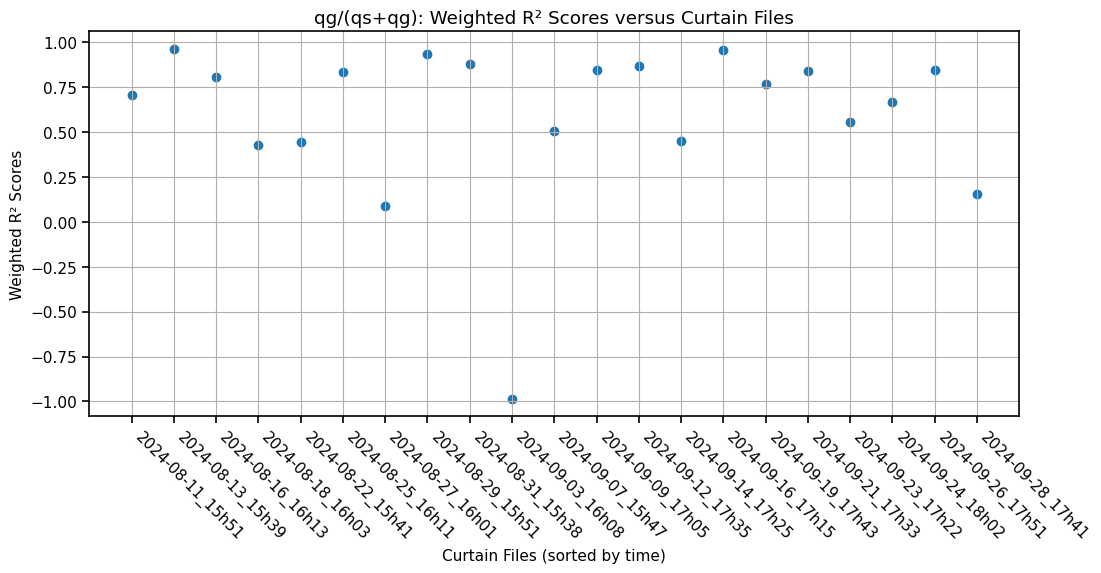

In [ ]:
import re

#Extract time from filenames
labels = [re.search(r'(\d{4}-\d{2}-\d{2}_\d{2}h\d{2})', f).group(1) for f in files]

plt.figure(figsize=(12, 5))
# plt.scatter(range(len(files)), r2_curtain_list, marker='o', label='R² Score')
# plt.scatter(range(len(files)), modified_r2_curtain_list, marker='s', label='Modified R² Score')
# plt.scatter(range(len(files)), weighted_r2_curtain_list, marker='o', label='Weighted R² Score')
plt.scatter(range(len(files)), weighted_r2_curtain_list, marker='o')
plt.xticks(range(len(files)), labels, rotation=-45, ha='left')
plt.xlabel('Curtain Files (sorted by time)')
plt.ylabel('Weighted R² Scores')
plt.title('ql/(ql+qi): Weighted R² Scores versus Curtain Files')     
plt.grid()
# plt.legend()
# plt.legend(loc='lower left')
plt.savefig(f"../output/{output_folder_name}/Weighted_R2_Scores_vs_Curtain_Files.png", dpi=300, bbox_inches="tight")
plt.show()  

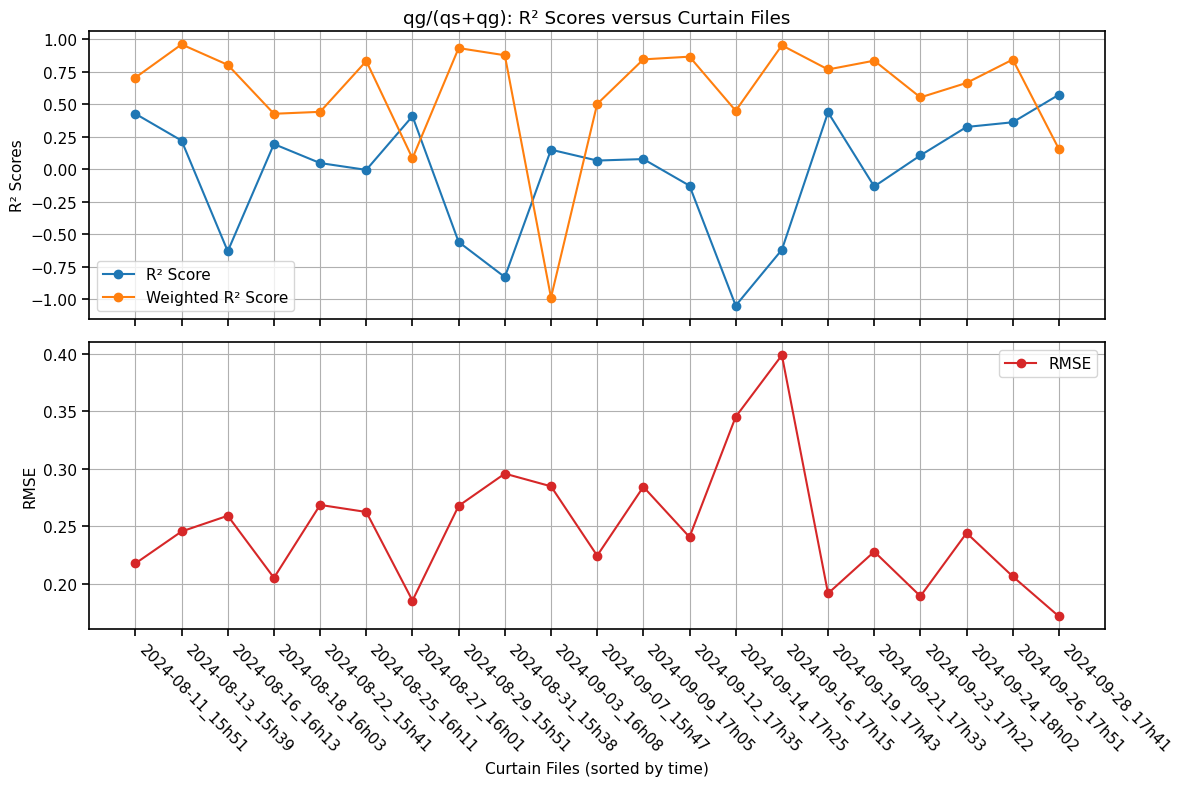

In [ ]:
import re

#Extract time from filenames
labels = [re.search(r'(\d{4}-\d{2}-\d{2}_\d{2}h\d{2})', f).group(1) for f in files]

x=range(len(files))
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

#Top plot for R² scores

ax1.plot(x, r2_curtain_list, marker='o', label='R² Score')
ax1.plot(x, weighted_r2_curtain_list, marker='o', label='Weighted R² Score')
ax1.set_ylabel('R² Scores')
ax1.set_title('ql/(ql+qi): R² Scores versus Curtain Files')     
ax1.grid()
# ax1.legend(loc='lower left')
ax1.legend()

#Bottom plot for RMSE
ax2.plot(x, rmse_curtain_list, marker='o', color='tab:red', label='RMSE')
ax2.set_ylabel('RMSE')
ax2.set_xlabel('Curtain Files (sorted by time)')
ax2.grid()
ax2.legend()


#Common x-ticks
plt.xticks(x, labels, rotation=-45, ha='left')
plt.tight_layout()

plt.savefig(f"../output/{output_folder_name}/RMSE_and_Multiple_R2_Scores_vs_Curtain_Files.png", dpi=300, bbox_inches="tight")
plt.show()  


ql+qi: 33.9831 %
RH: 18.4906 %
qr+qg+qs: 14.8309 %
T: 14.7233 %
P: 4.2631 %
upward_air_velocity: 4.2483 %
lat: 3.4449 %
lon: 2.6615 %
zonal_wind: 1.7153 %
meridional_wind: 1.6390 %


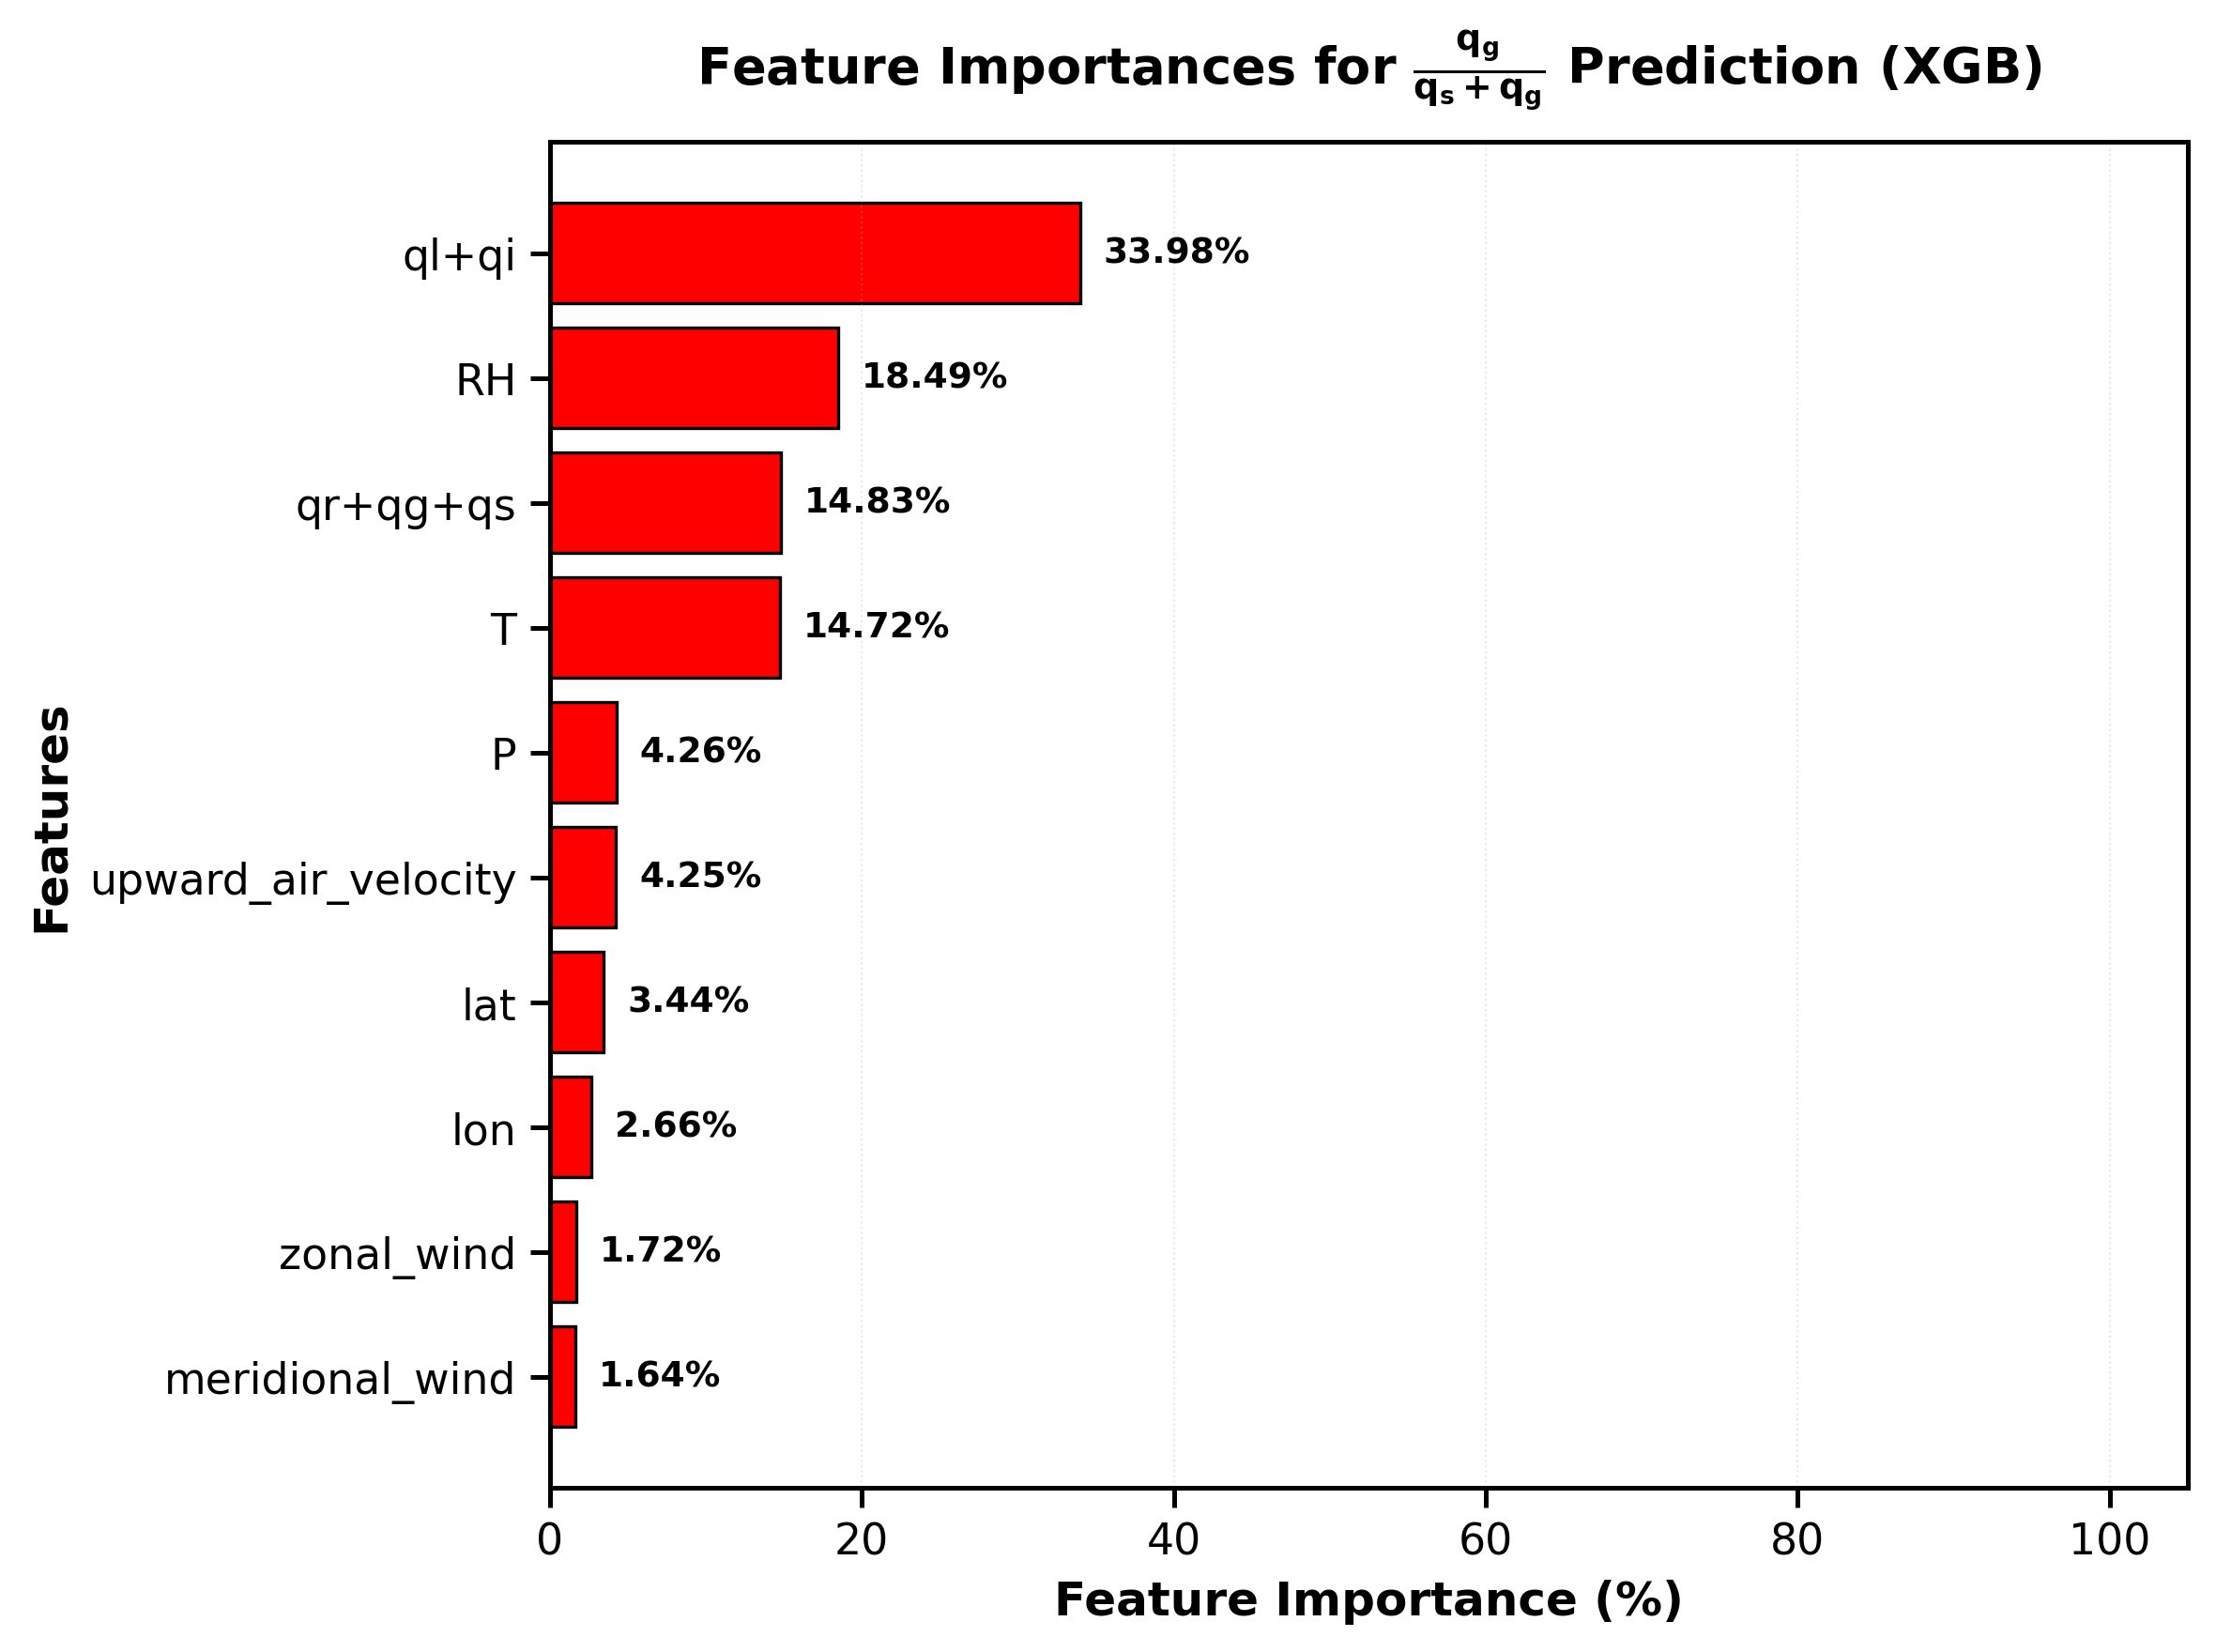

In [ ]:
#Re-run this block

#Feature importance plot
importance = model.feature_importances_

#Combine feature names and scores
feature_scores = list(zip(feature_names, importance))

#Sort by score in descending order
feature_scores.sort(key=lambda x: x[1], reverse=True)

#Convert to percentages
names = []
importances = []

for name, score in feature_scores:
    pct = score * 100
    names.append(name)
    importances.append(pct)
    print(f"{name}: {pct:.4f} %")

fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

bars = ax.barh(names, importances, color='red', edgecolor='black', linewidth=0.8)


ax.set_xlabel("Feature Importance (%)", fontsize=12, fontweight='bold')
ax.set_ylabel("Features", fontsize=12, fontweight='bold')
#ax.set_title(r"XGBoost Feature Importance: Ice-Phase Hydrometeor Fraction $\mathbf{\left(\frac{q_g}{q_s + q_g}\right)}$", 
ax.set_title(r"Feature Importances for $\mathbf{\frac{q_l}{q_l + q_i}}$ Prediction (XGB)", 
            fontsize=13, fontweight='bold', pad=15)

ax.invert_yaxis() #Highest importance at the top

#Add percentage values on bars
for bar in bars:
    width = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    ax.text(
        width + 1.5,
        y,
        f"{width:.2f}%",
        va="center",
        fontsize=9,
        fontweight='bold'
    )
ax.set_xlim(0, 105)

ax.grid(True, axis='x', alpha=0.3, linestyle=':', linewidth=0.5, zorder=0)

plt.tight_layout()
plt.savefig(f"../output/{output_folder_name}/FeatureImportance.png",
    dpi=300, bbox_inches='tight')

plt.show()


In [ ]:
overall_end_time = time.time()
overall_elapsed_time = overall_end_time - overall_start_time
print(f"Overall Elapsed time: {overall_elapsed_time/60:.4f} minutes")

Overall Elapsed time: 11.8596 minutes
